# V13 – Rechnerarchitektur: Praxis – Daten visualisieren mit matplotlib

## 🎯 Lernziele
Nach diesem Notebook kannst du …
- einfache **Balkendiagramme** mit `matplotlib.pyplot.bar()` erstellen,
- deine Plots mit **Titel** und **Achsenbeschriftungen** versehen,
- **Messreihen** aus dem Maschinenbau (z. B. Werkzeugverschleiß) sichtbar machen,
- Balken **einfärben** und X-Labels **drehen**, damit lange Namen lesbar bleiben.

## ⏱️ Zeitbudget
Ca. 30 Minuten.

## 🧭 TL;DR
**matplotlib** ist die Standard-Bibliothek in Python, um Daten grafisch darzustellen. Mit `plt.bar(kategorien, werte)` zeichnest du ein Balkendiagramm; `plt.title`, `plt.xlabel`, `plt.ylabel` und `plt.show` vervollständigen den Plot.

## 📦 Voraussetzungen
- V13 Theorie (`01_theorie.ipynb`) – wenigstens überflogen
- Python-Grundlagen aus V01–V08 (Listen, `for`, Funktionen)
- Paket `matplotlib` (siehe `requirements.txt`)


## 1. Warum überhaupt Plots?

Im Maschinenbau fallen ständig **Messreihen** an: Temperaturen an einem Lager, Verschleiß eines Werkzeugs nach jeder Schicht, Ausschussraten einer Fertigungszelle. Als reine Zahlenkolonne in einer Tabelle sind diese Werte für Menschen schwer zu überblicken – erst ein Diagramm macht Trends, Ausreißer und Muster unmittelbar sichtbar.

Ein **Balkendiagramm** vergleicht Werte zwischen **diskreten Kategorien** (z. B. fünf verschiedene Werkzeuge, drei Maschinen, vier Schichten). Es beantwortet die Frage: *„Welche Kategorie hat den höchsten/niedrigsten Wert?"* schneller als jede Tabelle.

Die Python-Bibliothek **matplotlib** liefert genau dafür die nötigen Funktionen. Wir nutzen das Submodul `matplotlib.pyplot` und importieren es nach Konvention als `plt`.


In [1]:
# Standard-Import von matplotlib. 'plt' ist der übliche Kurzname.
import matplotlib.pyplot as plt

# Wir sagen matplotlib, dass Plots inline im Notebook erscheinen sollen
# (bei nbconvert und in VS Code ist das ohnehin der Standard).
print("matplotlib ist bereit:", plt.__name__)


Matplotlib is building the font cache; this may take a moment.


matplotlib ist bereit: matplotlib.pyplot


## 2. Der erste Plot

Die wichtigste Funktion für uns ist `plt.bar(x, hoehen)`. Sie bekommt zwei Listen: die **Positionen** der Balken auf der X-Achse und die **Höhen** der Balken auf der Y-Achse.

Am einfachsten startest du mit Zahlen `[1, 2, 3]` als Positionen und irgendwelchen Messwerten als Höhen. Mit `plt.show()` sagst du matplotlib: „Jetzt das Diagramm anzeigen." Ohne `plt.show()` wird in Skripten manchmal gar nichts dargestellt.


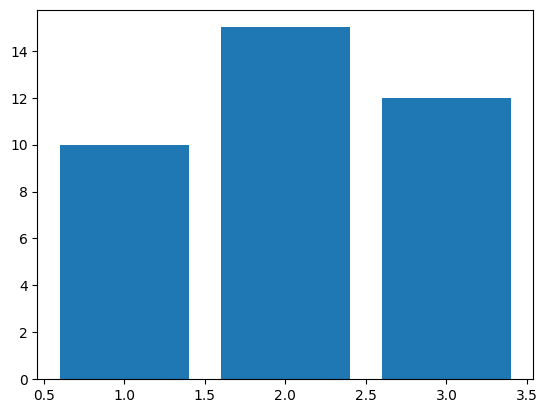

In [2]:
import matplotlib.pyplot as plt

# Einfachster Balkendiagramm-Aufruf: drei Positionen, drei Höhen.
plt.figure()
plt.bar([1, 2, 3], [10, 15, 12])
plt.show()


Du siehst drei Balken unterschiedlicher Höhe. Die X-Achse zeigt `1, 2, 3`, die Y-Achse die Werte. Das Diagramm ist **korrekt**, aber es fehlt jede inhaltliche Einordnung: Was bedeuten die Zahlen? In welcher Einheit? Genau das regeln **Titel** und **Achsenbeschriftungen** im nächsten Abschnitt.


## 3. Achsen beschriften – Pflicht, nicht Kür

Ein Diagramm ohne Beschriftung ist in einer Ingenieur-Präsentation wertlos. Drei Funktionen reichen, um es aussagekräftig zu machen:

- `plt.title("...")` setzt den **Titel** des Plots.
- `plt.xlabel("...")` beschriftet die **X-Achse**.
- `plt.ylabel("...")` beschriftet die **Y-Achse** (hier nennst du immer die **Einheit**, z. B. `"Verschleiß in mm"`).

Die Aufrufe müssen **vor** `plt.show()` stehen, sonst werden sie dem nächsten Diagramm zugeordnet.


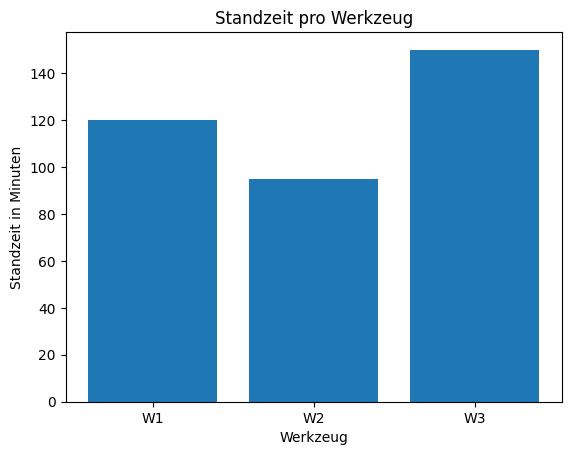

In [3]:
import matplotlib.pyplot as plt

werkzeuge = ["W1", "W2", "W3"]
standzeiten = [120, 95, 150]  # Standzeit in Minuten bis Verschleißgrenze

plt.figure()
plt.bar(werkzeuge, standzeiten)
plt.title("Standzeit pro Werkzeug")
plt.xlabel("Werkzeug")
plt.ylabel("Standzeit in Minuten")
plt.show()


## 4. Mit echten Maschinenbau-Daten arbeiten

Stell dir vor, du hast den **Werkzeugverschleiß** von fünf CNC-Maschinen nach einer 8-Stunden-Schicht gemessen. Du bekommst zwei parallele Listen: die **Maschinen-Namen** und den **gemessenen Verschleiß** in Millimetern.

Das Muster ist immer dasselbe:

1. Zwei Listen vorbereiten – eine für **Kategorien** (X-Achse), eine für **Werte** (Y-Achse).
2. `plt.bar(kategorien, werte)` aufrufen.
3. Titel und Achsen beschriften.
4. `plt.show()` – fertig.


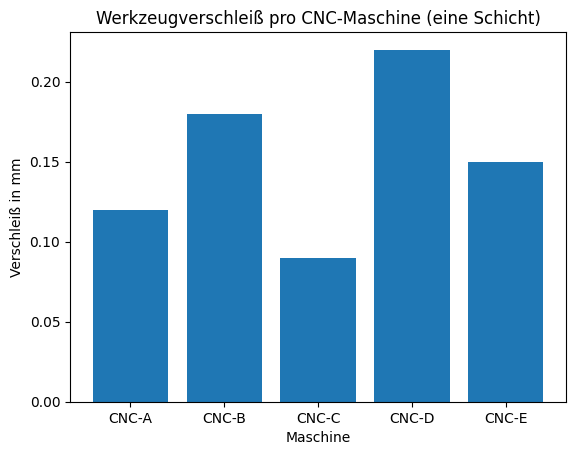

Höchster Verschleiß: 0.22 mm
Niedrigster Verschleiß: 0.09 mm


In [4]:
import matplotlib.pyplot as plt

maschinen = ["CNC-A", "CNC-B", "CNC-C", "CNC-D", "CNC-E"]
verschleiss = [0.12, 0.18, 0.09, 0.22, 0.15]  # in mm pro Schicht

plt.figure()
plt.bar(maschinen, verschleiss)
plt.title("Werkzeugverschleiß pro CNC-Maschine (eine Schicht)")
plt.xlabel("Maschine")
plt.ylabel("Verschleiß in mm")
plt.show()

print("Höchster Verschleiß:", max(verschleiss), "mm")
print("Niedrigster Verschleiß:", min(verschleiss), "mm")


## 5. Farbe und gedrehte X-Labels

Zwei kleine Verbesserungen, die du in fast jedem Report brauchst:

- Mit `color="..."` färbst du alle Balken einheitlich ein (`"steelblue"`, `"orange"`, `"#2e7d32"` …).
- Lange Kategorie-Namen überlappen schnell. `plt.xticks(rotation=45)` dreht die X-Labels um 45°, dann sind sie wieder lesbar.

Das reicht für 95 % aller Standard-Plots.


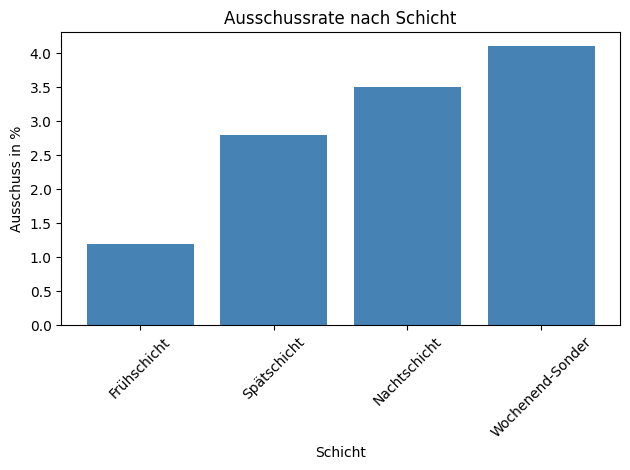

In [5]:
import matplotlib.pyplot as plt

schichten = ["Frühschicht", "Spätschicht", "Nachtschicht", "Wochenend-Sonder"]
ausschuss_prozent = [1.2, 2.8, 3.5, 4.1]

plt.figure()
plt.bar(schichten, ausschuss_prozent, color="steelblue")
plt.title("Ausschussrate nach Schicht")
plt.xlabel("Schicht")
plt.ylabel("Ausschuss in %")
plt.xticks(rotation=45)
plt.tight_layout()  # sorgt dafür, dass gedrehte Labels nicht abgeschnitten werden
plt.show()


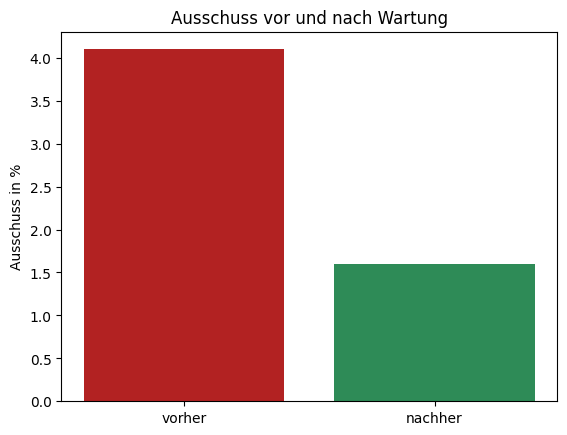

In [6]:
import matplotlib.pyplot as plt

# Kurze Variante mit farbigen Balken und zweiter Farbe zum Vergleich.
plt.figure()
plt.bar(["vorher", "nachher"], [4.1, 1.6], color=["firebrick", "seagreen"])
plt.title("Ausschuss vor und nach Wartung")
plt.ylabel("Ausschuss in %")
plt.show()


## 🧩 Fill-in #1 – Titel ergänzen

Im folgenden Plot fehlt der Titel. Ergänze in der Zeile mit `# TODO` den passenden Titel-String **„Lagertemperatur je Messpunkt"**. Der Selbstcheck liest den Titel mit `plt.gca().get_title()` aus.


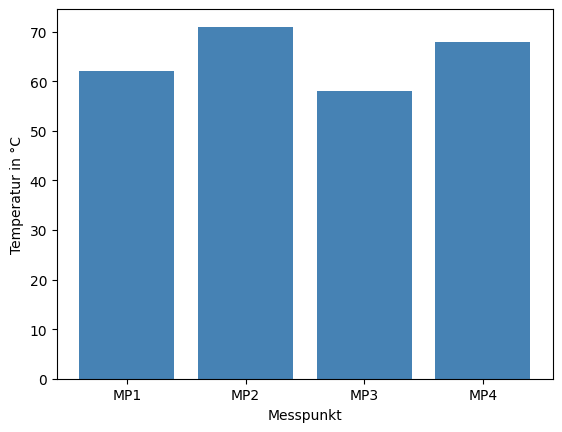

❌ Noch nicht richtig: Titel stimmt noch nicht, aktuell: ''


In [7]:
import matplotlib.pyplot as plt

messpunkte = ["MP1", "MP2", "MP3", "MP4"]
temperaturen = [62, 71, 58, 68]  # in °C

plt.figure()
plt.bar(messpunkte, temperaturen, color="steelblue")

# TODO: Ersetze den leeren String durch den Titel "Lagertemperatur je Messpunkt".
plt.title("")

plt.xlabel("Messpunkt")
plt.ylabel("Temperatur in °C")
titel_gesetzt = plt.gca().get_title()
plt.show()

# ▶️ Selbstkontrolle
try:
    assert titel_gesetzt == "Lagertemperatur je Messpunkt", \
        f"Titel stimmt noch nicht, aktuell: '{titel_gesetzt}'"
    print("✅ Titel ist korrekt gesetzt.")
except AssertionError as e:
    print("❌ Noch nicht richtig:", e)
except NameError as e:
    print("❌ Variable fehlt:", e)


## 🧩 Fill-in #2 – X-Achse beschriften

Dem nächsten Plot fehlt die X-Achsen-Beschriftung. Ergänze den passenden Aufruf `plt.xlabel("Baugruppe")`. Der Selbstcheck fragt `plt.gca().get_xlabel()` ab.


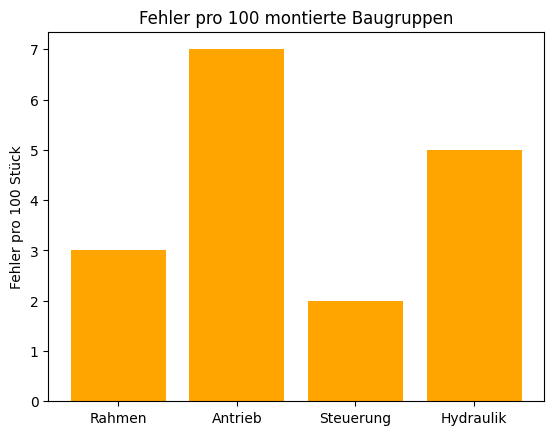

❌ Noch nicht richtig: xlabel stimmt noch nicht, aktuell: ''


In [8]:
import matplotlib.pyplot as plt

baugruppen = ["Rahmen", "Antrieb", "Steuerung", "Hydraulik"]
fehler_pro_100 = [3, 7, 2, 5]

plt.figure()
plt.bar(baugruppen, fehler_pro_100, color="orange")
plt.title("Fehler pro 100 montierte Baugruppen")

# TODO: Ergänze hier den fehlenden xlabel-Aufruf (Text: "Baugruppe").
plt.xlabel("")

plt.ylabel("Fehler pro 100 Stück")
xlabel_gesetzt = plt.gca().get_xlabel()
plt.show()

# ▶️ Selbstkontrolle
try:
    assert xlabel_gesetzt == "Baugruppe", \
        f"xlabel stimmt noch nicht, aktuell: '{xlabel_gesetzt}'"
    print("✅ X-Achse ist beschriftet.")
except AssertionError as e:
    print("❌ Noch nicht richtig:", e)
except NameError as e:
    print("❌ Variable fehlt:", e)


## 🧩 Fill-in #3 – Balkenhöhen eintragen

Du willst die Produktionsstückzahlen der letzten vier Quartale plotten. Die Kategorien stehen schon da, aber die Liste `stueckzahlen` ist noch leer. Ergänze sie mit den Werten `[1200, 1350, 1500, 1420]` (in dieser Reihenfolge). Der Selbstcheck prüft die **Summe** der Werte.


In [9]:
import matplotlib.pyplot as plt

quartale = ["Q1", "Q2", "Q3", "Q4"]

# TODO: Trage die vier Stückzahlen in dieser Reihenfolge ein: 1200, 1350, 1500, 1420
stueckzahlen = []

if len(stueckzahlen) == len(quartale):
    plt.figure()
    plt.bar(quartale, stueckzahlen, color="seagreen")
    plt.title("Produktion pro Quartal")
    plt.xlabel("Quartal")
    plt.ylabel("Stückzahl")
    plt.show()
else:
    print("Noch keine Werte eingetragen – Plot wird erst nach TODO erzeugt.")

# ▶️ Selbstkontrolle
try:
    assert len(stueckzahlen) == 4, f"Liste muss 4 Werte haben, hat aber {len(stueckzahlen)}"
    assert sum(stueckzahlen) == 5470, f"Summe erwartet 5470, bekommen: {sum(stueckzahlen)}"
    print("✅ Stückzahlen sind korrekt eingetragen.")
except AssertionError as e:
    print("❌ Noch nicht richtig:", e)
except NameError as e:
    print("❌ Variable fehlt:", e)


Noch keine Werte eingetragen – Plot wird erst nach TODO erzeugt.
❌ Noch nicht richtig: Liste muss 4 Werte haben, hat aber 0


## 🏁 Mini-Challenge

Erstelle **einen eigenen Balkenplot** mit **mindestens vier** selbst gewählten Werten aus dem Maschinenbau-Kontext (z. B. Laufleistung verschiedener Lager, Taktzeiten verschiedener Stationen, Energieverbrauch verschiedener Antriebe). **Alles beschriften**: Titel, X-Achse, Y-Achse – und `plt.show()` nicht vergessen.

Der Selbstcheck prüft, ob Titel, X-Label und Y-Label **alle nicht leer** sind.


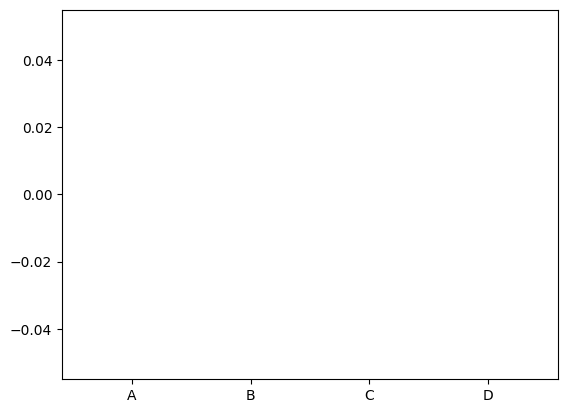

❌ Noch nicht ganz: Titel fehlt noch.


In [10]:
import matplotlib.pyplot as plt

# TODO: Definiere eigene Kategorien und Werte (mind. 4) und beschrifte alles.
kategorien = ["A", "B", "C", "D"]
werte = [0, 0, 0, 0]  # TODO: sinnvolle Werte einsetzen

plt.figure()
plt.bar(kategorien, werte, color="steelblue")
plt.title("")   # TODO: Titel
plt.xlabel("")  # TODO: X-Achse
plt.ylabel("")  # TODO: Y-Achse (mit Einheit!)
titel = plt.gca().get_title()
xl = plt.gca().get_xlabel()
yl = plt.gca().get_ylabel()
plt.show()

# ▶️ Selbstkontrolle
try:
    assert titel != "", "Titel fehlt noch."
    assert xl != "", "X-Label fehlt noch."
    assert yl != "", "Y-Label fehlt noch."
    assert sum(werte) > 0, "Setze mindestens einen Wert > 0."
    print("✅ Mini-Challenge gelöst: Plot ist vollständig beschriftet.")
except AssertionError as e:
    print("❌ Noch nicht ganz:", e)
except NameError as e:
    print("❌ Variable fehlt:", e)


## ✅ Zusammenfassung
- `plt.bar(kategorien, werte)` zeichnet ein Balkendiagramm.
- **Immer** mit `plt.title`, `plt.xlabel`, `plt.ylabel` beschriften – Y-Achse mit Einheit.
- `color="..."` färbt alle Balken, `plt.xticks(rotation=45)` dreht lange Labels.
- `plt.show()` gehört ans Ende jeder Plot-Zelle; `plt.figure()` startet bei Bedarf ein frisches Diagramm.

## ➡️ Nächster Schritt
Weiter mit [03_aufgaben.ipynb](03_aufgaben.ipynb) – dort wendest du das Gelernte auf echte Maschinendaten an.
